### Author: Guilherme Oliveira
### Contact: gmmoliveira1@gmail.com
### Date: march-13-2026

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from pathlib import Path
import os
import numpy as np
from typing import Dict, Iterable, Optional, Tuple, List

from sklearn.model_selection import TimeSeriesSplit
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
from IPython.display import display

import shap
import networkx as nx
from dowhy import CausalModel
from pgmpy.estimators import HillClimbSearch, BIC as BicScore
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


## Config Constants

In [2]:
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")


FEATURE_CUTOFF = None  # e.g., pd.Timestamp("2025-01-31")
HORIZON_MONTHS = 12
SNAPSHOT_FREQ = "MS"  # monthly snapshot at month start
K_FOLDS = 10

TARGET_SCORE = "F1"
ASC_TARGET_SCORE = False

# --------------------
# Modeling configuration
# --------------------
TIME_COL = "cutoff_date"
RESIDENT_COL = "resident_id"
FACILITY_COL = "facility_id"
TASK1_TARGET_COL = "target_incident_next_horizon"
TASK2_TARGET_COL = "target_incident_type_next_horizon"
DROP_FEATURE_COLS = [RESIDENT_COL, FACILITY_COL, TIME_COL]

# Reproducibility controls used by the models below.
RANDOM_STATE = 1345673247
MAX_ITER_LOGREG = 1000

# Evaluation controls
METRIC_COLUMNS = ["acc", "bal_acc", "F1", "precision", "recall", "TPR", "FNR", "roc_auc"]
LOWER_IS_BETTER_METRICS = {"FNR"}

# Baseline model names to test.
MODEL_NAMES = [
    "gaussian_nb",
    "bernoulli_nb",
    "logistic_regression",
    "random_forest",
    "lightgbm",
    "knn",
    "mlp",
    "ridge_classifier",
    "linear_svc",
    "radius_neighbors",
]

In [3]:
table_names = [
    "adl_responses",
    "care_plans",
    "diagnoses",
    "document_tags",
    "factors",
    "gg_responses",
    "hospital_admissions",
    "hospital_transfers",
    "incidents",
    "injuries",
    "lab_reports",
    "medications",
    "needs",
    "physician_orders",
    "residents",
    "therapy_tracks",
    "vitals",
]

## Utils

In [4]:
tables = {
    name: pd.read_parquet(os.path.join(DATA_DIR, f"{name}.parquet"))
    for name in table_names
}

## Prediction Tasks

Constructed two supervised learning tasks based on resident–month snapshots at time `cutoff_date`.

### Task 1 – Incident occurrence (binary classification)

For each row (resident, cutoff_date), we define a binary target:

- `target_incident_next_horizon = 0`  
  No incident of any type occurs for this resident in the semi open interval  
  (`cutoff_date`, `cutoff_date` + `horizon_months`].

- `target_incident_next_horizon = 1`  
  At least one incident of any type occurs for this resident in the same interval.

This task uses **all snapshot rows**.

### Task 2 – Incident type (multi-class classification)

For each row where `target_incident_next_horizon = 1`, we define:

- `target_incident_type_next_horizon` = incident type (e.g. *Fall*, *Medication error*, *Wound*, etc.) of the **first** incident in `cutoff_date`, `cutoff_date` + `horizon_months`.

Task 2 is trained only on rows with `target_incident_next_horizon = 1`.

## Time-aware Feature Engineering and Target Construction

Build resident-level monthly snapshots and engineer historical features using only information available up to each snapshot cutoff date. Then create two supervised-learning datasets:

1. **Incident occurrence** in the next `horizon_months` (binary target).
2. **Incident type** for the first incident occurring in that horizon (multi-class target, positive rows only).

The pipeline is parameterized by a global `feature_cutoff` to support strict past-vs-future validation splits.

In [5]:
def _ensure_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Convert common date/time columns to pandas datetime in a defensive way."""
    out = df.copy()
    datetime_like = [
        c for c in out.columns if c.endswith("_at") or c.endswith("_date")
    ]
    for col in datetime_like:
        out[col] = pd.to_datetime(out[col], errors="coerce")
    return out


def preprocess_tables(raw_tables: Dict[str, pd.DataFrame]) -> Dict[str, pd.DataFrame]:
    """Basic cleaning with a strong preference to keep rows (high recall)."""
    cleaned = {}

    for name, df in raw_tables.items():
        cur = _ensure_datetime_columns(df)

        # Remove logically deleted/invalid rows when explicit flags exist.
        if "strikeout" in cur.columns:
            before = len(cur)
            cur = cur[cur["strikeout"] == False].copy()  # noqa: E712
            print(f"[{name}] strikeout filter: {before:,} -> {len(cur):,}")

        if "deleted_at" in cur.columns:
            before = len(cur)
            cur = cur[cur["deleted_at"].isna()].copy()
            print(f"[{name}] deleted_at filter: {before:,} -> {len(cur):,}")

        cleaned[name] = cur
        print(f"[{name}] final shape: {cur.shape}")

    return cleaned


def infer_feature_cutoff(tables_: Dict[str, pd.DataFrame]) -> pd.Timestamp:
    """Infer a global cutoff using the latest known event timestamp."""
    candidate_cols = [
        ("incidents", "occurred_at"),
        ("vitals", "measured_at"),
        ("medications", "scheduled_at"),
        ("hospital_transfers", "effective_date"),
        ("hospital_admissions", "effective_date"),
    ]

    max_values = []
    for tname, c in candidate_cols:
        if tname in tables_ and c in tables_[tname].columns:
            val = tables_[tname][c].max()
            if pd.notna(val):
                max_values.append(pd.Timestamp(val))

    if not max_values:
        raise ValueError("Unable to infer feature cutoff from provided tables.")

    cutoff = min(max_values)
    print(f"Inferred global feature cutoff: {cutoff}")
    return cutoff


def build_resident_snapshots(
    residents: pd.DataFrame,
    feature_cutoff: pd.Timestamp,
    freq: str = "MS",
) -> pd.DataFrame:
    """
    Build resident-level time snapshots.

    Each row is one resident at one cutoff date, and will become a supervised
    sample after feature and target construction.
    """
    res = residents.copy()

    # End of observable residency for feature generation (capped by global cutoff).
    res["resident_end"] = res[["discharge_date", "deceased_date"]].min(axis=1)
    res["resident_end"] = res["resident_end"].fillna(feature_cutoff)
    res["resident_end"] = res["resident_end"].clip(upper=feature_cutoff)

    snapshot_frames = []

    for _, row in res.iterrows():
        admission = row["admission_date"]
        end_date = row["resident_end"]

        if pd.isna(admission) or pd.isna(end_date):
            continue

        start = pd.Timestamp(admission).to_period("M").to_timestamp(how="start")
        end = pd.Timestamp(end_date).to_period("M").to_timestamp(how="start")

        if end < start:
            continue

        cutoffs = pd.date_range(start=start, end=end, freq=freq)
        if len(cutoffs) == 0:
            continue

        frame = pd.DataFrame(
            {
                "resident_id": row["resident_id"],
                "facility_id": row["facility_id"],
                "cutoff_date": cutoffs,
            }
        )
        snapshot_frames.append(frame)

    if not snapshot_frames:
        raise ValueError("No resident snapshots were generated. Check admission/discharge dates and cutoff.")

    snapshots = pd.concat(snapshot_frames, ignore_index=True)

    # Attach resident-level static/semi-static attributes.
    keep_cols = [
        "resident_id",
        "date_of_birth",
        "admission_date",
        "discharge_date",
        "deceased_date",
        "outpatient",
    ]
    snapshots = snapshots.merge(res[keep_cols], on="resident_id", how="left")

    snapshots["age_years"] = (
        (snapshots["cutoff_date"] - snapshots["date_of_birth"]).dt.days / 365.25
    )
    snapshots["length_of_stay_days"] = (
        snapshots["cutoff_date"] - snapshots["admission_date"]
    ).dt.days

    snapshots["is_currently_admitted"] = (
        (snapshots["discharge_date"].isna() | (snapshots["discharge_date"] > snapshots["cutoff_date"]))
        & (snapshots["deceased_date"].isna() | (snapshots["deceased_date"] > snapshots["cutoff_date"]))
    ).astype(int)

    print(
        "Resident snapshots built:",
        f"{len(snapshots):,} rows, {snapshots['resident_id'].nunique():,} residents",
    )
    print("Cutoff range:", snapshots["cutoff_date"].min(), "->", snapshots["cutoff_date"].max())

    return snapshots


def build_time_index(
    df: pd.DataFrame,
    time_col: str,
    feature_cutoff: pd.Timestamp,
) -> Dict[str, np.ndarray]:
    """Build per-resident sorted event-time arrays up to feature_cutoff."""
    # Defensive guard: some source tables may not have resident_id.
    if time_col not in df.columns or "resident_id" not in df.columns:
        return {}

    cur = df[["resident_id", time_col]].dropna(subset=["resident_id", time_col]).copy()
    cur = cur[cur[time_col] <= feature_cutoff]

    index = {
        rid: np.sort(grp[time_col].to_numpy(dtype="datetime64[ns]"))
        for rid, grp in cur.groupby("resident_id")
    }
    return index


def add_event_count_features(
    snapshots: pd.DataFrame,
    event_index: Dict[str, np.ndarray],
    prefix: str,
    windows_days: Iterable[int] = (30, 90, 180, 365),
) -> pd.DataFrame:
    """
    Add windowed event counts and recency-by-resident for one event source.

    This function avoids row-dropping and keeps NaNs where history is unavailable.
    """
    out = snapshots.copy()
    n = len(out)
    cutoff_ns = out["cutoff_date"].to_numpy(dtype="datetime64[ns]")

    feature_arrays = {
        f"{prefix}_count_{w}d": np.zeros(n, dtype=np.float32) for w in windows_days
    }
    feature_arrays[f"{prefix}_days_since_last"] = np.full(n, np.nan, dtype=np.float32)

    resident_positions = out.groupby("resident_id").indices

    for rid, pos in resident_positions.items():
        times = event_index.get(rid)
        if times is None or len(times) == 0:
            continue

        cut = cutoff_ns[pos]
        right = np.searchsorted(times, cut, side="right")

        for w in windows_days:
            left = np.searchsorted(times, cut - np.timedelta64(w, "D"), side="right")
            feature_arrays[f"{prefix}_count_{w}d"][pos] = (right - left).astype(np.float32)

        last_idx = right - 1
        valid_last = last_idx >= 0
        if valid_last.any():
            last_times = times[last_idx[valid_last]]
            days_since = (cut[valid_last] - last_times) / np.timedelta64(1, "D")
            feature_arrays[f"{prefix}_days_since_last"][np.array(pos)[valid_last]] = days_since.astype(np.float32)

    for col, arr in feature_arrays.items():
        out[col] = arr

    print(f"Added features for '{prefix}': {len(feature_arrays)} columns")
    return out


def add_incident_history_type_features(
    snapshots: pd.DataFrame,
    incidents: pd.DataFrame,
    feature_cutoff: pd.Timestamp,
    window_days: int = 365,
) -> pd.DataFrame:
    """Add per-incident-type historical counts to help downstream type prediction."""
    out = snapshots.copy()
    inc = incidents[["resident_id", "incident_type", "occurred_at"]].dropna(subset=["incident_type", "occurred_at"])
    inc = inc[inc["occurred_at"] <= feature_cutoff].copy()

    incident_types = sorted(inc["incident_type"].astype(str).unique().tolist())
    print(f"Incident types in history features: {incident_types}")

    for t in incident_types:
        idx = build_time_index(inc[inc["incident_type"].astype(str) == t], "occurred_at", feature_cutoff)
        safe_t = t.lower().replace(" ", "_").replace("/", "_")
        out = add_event_count_features(
            out,
            idx,
            prefix=f"incident_type_{safe_t}",
            windows_days=(window_days,),
        )

    return out


def build_future_incident_labels(
    snapshots: pd.DataFrame,
    incidents: pd.DataFrame,
    horizon_months: int = 12,
) -> pd.DataFrame:
    """
    Build labels using a strict temporal rule:
    target window is (cutoff_date, cutoff_date + horizon_months].
    """
    inc = incidents[["resident_id", "occurred_at", "incident_type"]].dropna(subset=["occurred_at", "incident_type"]).copy()
    inc = inc.sort_values(["resident_id", "occurred_at"]).reset_index(drop=True)

    future_index: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}
    for rid, grp in inc.groupby("resident_id"):
        times = grp["occurred_at"].to_numpy(dtype="datetime64[ns]")
        types = grp["incident_type"].astype(str).to_numpy()
        future_index[rid] = (times, types)

    n = len(snapshots)
    cutoff_ns = snapshots["cutoff_date"].to_numpy(dtype="datetime64[ns]")
    horizon_end_ns = (snapshots["cutoff_date"] + pd.DateOffset(months=horizon_months)).to_numpy(dtype="datetime64[ns]")

    y_occ = np.zeros(n, dtype=np.int8)
    y_type = np.array([None] * n, dtype=object)
    y_first_time = np.full(n, np.datetime64("NaT"), dtype="datetime64[ns]")

    resident_positions = snapshots.groupby("resident_id").indices

    for rid, pos in resident_positions.items():
        payload = future_index.get(rid)
        if payload is None:
            continue

        times, types = payload
        cut = cutoff_ns[pos]
        end = horizon_end_ns[pos]

        left = np.searchsorted(times, cut, side="right")
        right = np.searchsorted(times, end, side="right")
        has_inc = right > left

        if not has_inc.any():
            continue

        pos_arr = np.array(pos)
        first_idx = left[has_inc]
        rows = pos_arr[has_inc]

        y_occ[rows] = 1
        y_type[rows] = types[first_idx]
        y_first_time[rows] = times[first_idx]

    labels = pd.DataFrame(
        {
            "target_incident_next_horizon": y_occ,
            "target_incident_type_next_horizon": y_type,
            "target_first_incident_at": y_first_time,
        },
        index=snapshots.index,
    )

    print("Label stats:")
    print(labels["target_incident_next_horizon"].value_counts(dropna=False).rename("count"))
    print("Incident type distribution (positives):")
    print(labels.loc[labels["target_incident_next_horizon"] == 1, "target_incident_type_next_horizon"].value_counts())

    return labels


def build_datasets(
    raw_tables: Dict[str, pd.DataFrame],
    feature_cutoff: Optional[pd.Timestamp] = None,
    horizon_months: int = 12,
    snapshot_freq: str = "MS",
) -> Dict[str, pd.DataFrame]:
    """Orchestrate end-to-end feature engineering and target construction."""
    clean = preprocess_tables(raw_tables)

    if feature_cutoff is None:
        feature_cutoff = infer_feature_cutoff(clean)
    feature_cutoff = pd.Timestamp(feature_cutoff)

    snapshots = build_resident_snapshots(
        clean["residents"],
        feature_cutoff=feature_cutoff,
        freq=snapshot_freq,
    )

    # Some tables (e.g., factors, injuries) are incident-level and need resident_id via incidents.
    incident_resident_map = clean["incidents"][["incident_id", "resident_id"]].drop_duplicates()

    factors_with_resident = clean["factors"].merge(
        incident_resident_map,
        on="incident_id",
        how="left",
    )
    injuries_with_resident = clean["injuries"].merge(
        incident_resident_map,
        on="incident_id",
        how="left",
    )

    # Event sources used for historical features.
    # Value = (dataframe_to_use, time_column)
    feature_sources = {
        "adl": (clean["adl_responses"], "created_at"),
        "care_plan": (clean["care_plans"], "initiated_at"),
        "diagnosis": (clean["diagnoses"], "created_at"),
        "document_tag": (clean["document_tags"], "created_at"),
        "factor": (factors_with_resident, "created_at"),
        "gg": (clean["gg_responses"], "created_at"),
        "hospital_adm": (clean["hospital_admissions"], "effective_date"),
        "hospital_transfer": (clean["hospital_transfers"], "effective_date"),
        "incident": (clean["incidents"], "occurred_at"),
        "injury": (injuries_with_resident, "created_at"),
        "lab": (clean["lab_reports"], "reported_at"),
        "med": (clean["medications"], "scheduled_at"),
        "need": (clean["needs"], "initiated_at"),
        "physician_order": (clean["physician_orders"], "ordered_at"),
        "therapy": (clean["therapy_tracks"], "start_at"),
        "vital": (clean["vitals"], "measured_at"),
    }

    features = snapshots.copy()
    for prefix, (source_df, time_col) in feature_sources.items():
        index = build_time_index(source_df, time_col, feature_cutoff=feature_cutoff)
        print(f"Building feature block: {prefix} ({time_col}), indexed residents={len(index):,}")
        features = add_event_count_features(features, index, prefix=prefix)

    # Add richer incident-history features for task 2.
    features = add_incident_history_type_features(
        features,
        clean["incidents"],
        feature_cutoff=feature_cutoff,
        window_days=365,
    )

    labels = build_future_incident_labels(
        snapshots=features[["resident_id", "cutoff_date"]],
        incidents=clean["incidents"],
        horizon_months=horizon_months,
    )

    full = pd.concat([features, labels], axis=1)

    cols2drop = [
        "target_incident_next_horizon",
        "target_incident_type_next_horizon",
        "target_first_incident_at",
        "date_of_birth",
        "admission_date",
        "discharge_date",
        "deceased_date",
        "outpatient",
    ]

    # Task 1: binary classification (all rows kept).
    task1 = full.copy()
    task1_X = task1.drop(columns=cols2drop)
    task1_y = task1[["target_incident_next_horizon"]].copy()

    # Task 2: multi-class classification only where an incident occurs in horizon.
    task2 = full[full["target_incident_next_horizon"] == 1].copy()
    task2_X = task2.drop(columns=cols2drop)
    task2_y = task2[["target_incident_type_next_horizon"]].copy()

    print("\nFinal dataset shapes")
    print(f"Task 1 - X: {task1_X.shape}, y: {task1_y.shape}")
    print(f"Task 2 - X: {task2_X.shape}, y: {task2_y.shape}")

    print("\nTemporal validation recommendation:")
    print(
        "Split by snapshot cutoff_date (past->future), e.g. train/valid on earlier months and test on latest months, "
        "to avoid time leakage."
    )

    return {
        "task1_X": task1_X,
        "task1_y": task1_y,
        "task2_X": task2_X,
        "task2_y": task2_y,
        "full_with_targets": full,
    }


# ---------------------------
# Run the end-to-end pipeline
# ---------------------------

artifacts = build_datasets(
    tables,
    feature_cutoff=FEATURE_CUTOFF,
    horizon_months=HORIZON_MONTHS,
    snapshot_freq=SNAPSHOT_FREQ,
)

# Persist outputs for downstream ML (features + targets only).
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

artifacts["task1_X"].to_parquet(OUTPUT_DIR / "task1_features.parquet", index=False)
artifacts["task1_y"].to_parquet(OUTPUT_DIR / "task1_target.parquet", index=False)
artifacts["task2_X"].to_parquet(OUTPUT_DIR / "task2_features.parquet", index=False)
artifacts["task2_y"].to_parquet(OUTPUT_DIR / "task2_target.parquet", index=False)

print("\nSaved outputs:")
print(OUTPUT_DIR / "task1_features.parquet")
print(OUTPUT_DIR / "task1_target.parquet")
print(OUTPUT_DIR / "task2_features.parquet")
print(OUTPUT_DIR / "task2_target.parquet")

[adl_responses] final shape: (480554, 12)
[care_plans] strikeout filter: 3,034 -> 2,716
[care_plans] final shape: (2716, 9)
[diagnoses] strikeout filter: 60,620 -> 58,067
[diagnoses] final shape: (58067, 8)
[document_tags] deleted_at filter: 562,905 -> 562,840
[document_tags] final shape: (562840, 9)
[factors] final shape: (190284, 5)
[gg_responses] final shape: (660711, 10)
[hospital_admissions] final shape: (2945, 9)
[hospital_transfers] final shape: (1816, 12)
[incidents] strikeout filter: 3,578 -> 3,382
[incidents] final shape: (3382, 8)
[injuries] final shape: (1219, 7)
[lab_reports] final shape: (13334, 9)
[medications] final shape: (1430877, 8)
[needs] strikeout filter: 162,762 -> 160,466
[needs] final shape: (160466, 11)
[physician_orders] final shape: (94051, 10)
[residents] final shape: (3000, 9)
[therapy_tracks] final shape: (761, 7)
[vitals] strikeout filter: 2,517,056 -> 2,512,667
[vitals] final shape: (2512667, 9)
Inferred global feature cutoff: 2025-01-31 13:57:00
Reside

In [6]:
assert artifacts["task1_X"].shape[0] ==artifacts["task1_y"].shape[0]
assert artifacts["task2_X"].shape[0] == artifacts["task2_y"].shape[0]

print(artifacts["task1_X"].shape)
print(artifacts["task1_y"].shape)
print(artifacts["task2_X"].shape)
print(artifacts["task2_y"].shape)

(31753, 98)
(31753, 1)
(6771, 98)
(6771, 1)


In [7]:
# prints unique values

display(artifacts["task1_y"]["target_incident_next_horizon"].unique())
display(artifacts["task2_y"]["target_incident_type_next_horizon"].unique())

array([0, 1], dtype=int8)

<ArrowStringArray>
['Fall', 'Wound', 'Medication Error', 'Altercation', 'Elopement', 'Choking']
Length: 6, dtype: str

verifies features for both tasks 1 and 2 are precisely the same.

In [8]:
assert len(set(artifacts["task1_X"].columns) - (set(artifacts["task2_X"].columns)) ) == 0
for c in artifacts["task1_X"].columns:
    print(f"- {c}")


- resident_id
- facility_id
- cutoff_date
- age_years
- length_of_stay_days
- is_currently_admitted
- adl_count_30d
- adl_count_90d
- adl_count_180d
- adl_count_365d
- adl_days_since_last
- care_plan_count_30d
- care_plan_count_90d
- care_plan_count_180d
- care_plan_count_365d
- care_plan_days_since_last
- diagnosis_count_30d
- diagnosis_count_90d
- diagnosis_count_180d
- diagnosis_count_365d
- diagnosis_days_since_last
- document_tag_count_30d
- document_tag_count_90d
- document_tag_count_180d
- document_tag_count_365d
- document_tag_days_since_last
- factor_count_30d
- factor_count_90d
- factor_count_180d
- factor_count_365d
- factor_days_since_last
- gg_count_30d
- gg_count_90d
- gg_count_180d
- gg_count_365d
- gg_days_since_last
- hospital_adm_count_30d
- hospital_adm_count_90d
- hospital_adm_count_180d
- hospital_adm_count_365d
- hospital_adm_days_since_last
- hospital_transfer_count_30d
- hospital_transfer_count_90d
- hospital_transfer_count_180d
- hospital_transfer_count_365d
- 

## Training

### Timeseries Cross Valiation

Cross validation is typically the method of choice for maximum robustness, however, we must also account for time constraints as no ML model should be trained on future data and tested on past data. The timeseries cross validation process is outlined by the following chart.

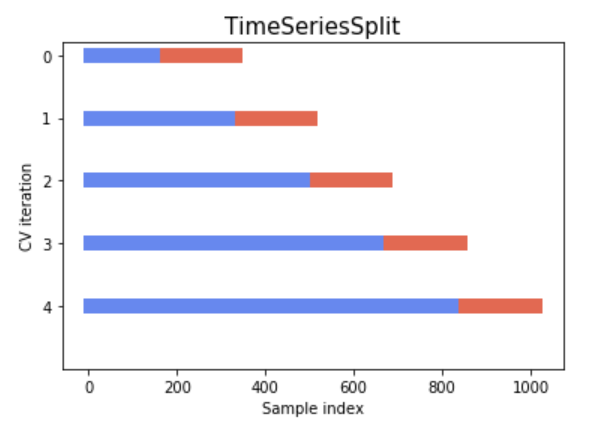


## Experiments: Leakage-safe Time Series Cross Validation

This section trains and evaluates multiple baseline classifiers for Task 1 (binary) and Task 2 (multi-class) using time-aware folds. The split logic uses `cutoff_date` while preventing resident overlap between train and test within each fold.

### Modeling Pipeline and Reporting

For each fold, imputers and encoders are fit on training data only, then applied to test data. Metrics are aggregated across folds and displayed in color-coded summary tables.

[Fold 1] skipped because training labels contain < 2 classes.
[Fold 2] skipped because training labels contain < 2 classes.
[Fold 3] skipped because training labels contain < 2 classes.
[Fold 4] skipped because training labels contain < 2 classes.
[Fold 5] skipped because training labels contain < 2 classes.
[Fold 6] skipped because training labels contain < 2 classes.
[Fold 7] skipped because training labels contain < 2 classes.
[Fold 8][radius_neighbors] skipped due to error.
[Fold 9][radius_neighbors] skipped due to error.
[Fold 10][radius_neighbors] skipped due to error.
Task 1 - Average cross-validation metrics :


,task,model,acc,bal_acc,F1,precision,recall,TPR,FNR,roc_auc
0,task1_incident_occurrence,bernoulli_nb,0.775085,0.594259,0.287279,0.373432,0.395499,0.395499,0.604501,0.702345
1,task1_incident_occurrence,mlp,0.823691,0.559397,0.243371,0.405050,0.191280,0.191280,0.808720,0.632459
2,task1_incident_occurrence,ridge_classifier,0.835176,0.556166,0.232305,0.619224,0.157790,0.157790,0.842210,0.615607
3,task1_incident_occurrence,gaussian_nb,0.814685,0.539826,0.193049,0.256896,0.179499,0.179499,0.820501,0.451492
4,task1_incident_occurrence,logistic_regression,0.837050,0.538247,0.163784,0.327612,0.126116,0.126116,0.873884,0.529244
5,task1_incident_occurrence,random_forest,0.840286,0.540723,0.161241,0.315066,0.130812,0.130812,0.869188,0.626638
6,task1_incident_occurrence,linear_svc,0.841200,0.536910,0.150443,0.363394,0.116362,0.116362,0.883638,0.532162
7,task1_incident_occurrence,lightgbm,0.836073,0.525410,0.123596,0.240747,0.089385,0.089385,0.910615,0.499421
8,task1_incident_occurrence,knn,0.829511,0.516211,0.103520,0.235255,0.074983,0.074983,0.925017,0.532851


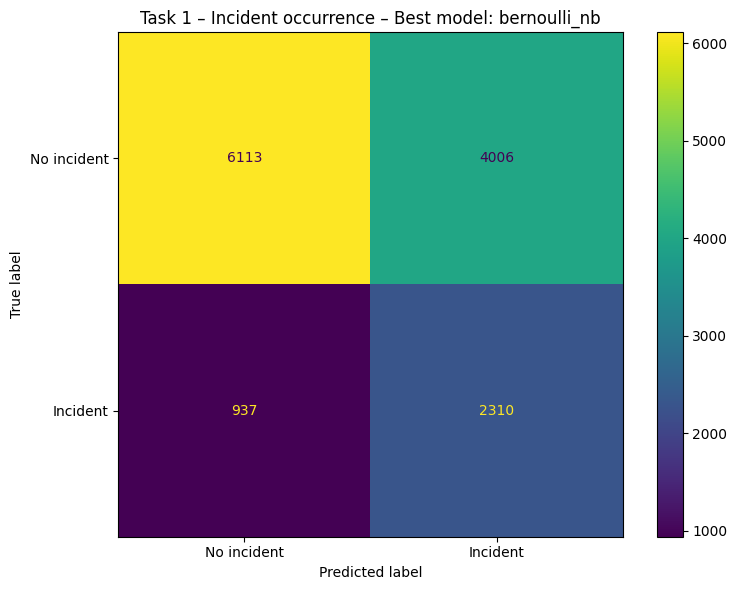

[Fold 1] skipped due to empty split after resident overlap filtering.
[Fold 2] skipped due to empty split after resident overlap filtering.
[Fold 3][gaussian_nb] skipped due to error.
[Fold 3][bernoulli_nb] skipped due to error.
[Fold 3][logistic_regression] skipped due to error.
[Fold 3][random_forest] skipped due to error.
[Fold 3][lightgbm] skipped due to error.
[Fold 3][knn] skipped due to error.
[Fold 3][mlp] skipped due to error.
[Fold 3][ridge_classifier] skipped due to error.
[Fold 3][linear_svc] skipped due to error.
[Fold 3][radius_neighbors] skipped due to error.
[Fold 4][gaussian_nb] skipped due to error.
[Fold 4][bernoulli_nb] skipped due to error.
[Fold 4][logistic_regression] skipped due to error.
[Fold 4][random_forest] skipped due to error.
[Fold 4][lightgbm] skipped due to error.
[Fold 4][knn] skipped due to error.
[Fold 4][mlp] skipped due to error.
[Fold 4][ridge_classifier] skipped due to error.
[Fold 4][linear_svc] skipped due to error.
[Fold 4][radius_neighbors] 

,task,model,acc,bal_acc,F1,precision,recall,TPR,FNR,roc_auc
0,task2_incident_type,lightgbm,0.628551,0.322339,0.258978,0.299053,0.322339,0.322339,0.677661,0.628959
1,task2_incident_type,random_forest,0.643080,0.277623,0.242563,0.288809,0.277623,0.277623,0.722377,0.634059
2,task2_incident_type,knn,0.562040,0.214120,0.217009,0.247979,0.214120,0.214120,0.785880,0.568131
3,task2_incident_type,mlp,0.510647,0.203736,0.204841,0.233925,0.203736,0.203736,0.796264,0.504880
4,task2_incident_type,logistic_regression,0.517624,0.241396,0.190113,0.214517,0.241396,0.241396,0.758604,0.564908
5,task2_incident_type,linear_svc,0.643249,0.205188,0.183123,0.208816,0.205188,0.205188,0.794812,0.591977
6,task2_incident_type,ridge_classifier,0.634566,0.201409,0.180920,0.214050,0.201409,0.201409,0.798591,0.565643
7,task2_incident_type,bernoulli_nb,0.454941,0.225434,0.173559,0.184477,0.225434,0.225434,0.774566,0.525313
8,task2_incident_type,gaussian_nb,0.314432,0.241832,0.133271,0.143340,0.241832,0.241832,0.758168,0.559941


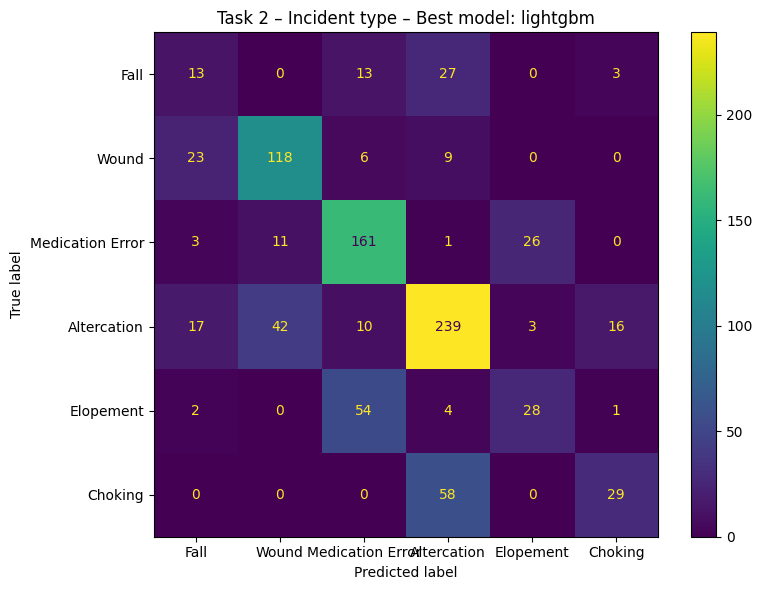

In [9]:
# Required baseline model list with default constructors.
MODEL_BUILDERS = {
    "gaussian_nb": lambda: GaussianNB(),
    "bernoulli_nb": lambda: BernoulliNB(),
    "logistic_regression": lambda: LogisticRegression(max_iter=MAX_ITER_LOGREG, random_state=RANDOM_STATE),
    "random_forest": lambda: RandomForestClassifier(random_state=RANDOM_STATE),
    "lightgbm": lambda: LGBMClassifier(verbosity=-1, random_state=RANDOM_STATE),
    "knn": lambda: KNeighborsClassifier(),
    "mlp": lambda: MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=RANDOM_STATE),
    "ridge_classifier": lambda: CalibratedClassifierCV(RidgeClassifier(random_state=RANDOM_STATE), cv=3),
    "linear_svc": lambda: CalibratedClassifierCV(LinearSVC(max_iter=MAX_ITER_LOGREG, random_state=RANDOM_STATE), cv=3),
    "radius_neighbors": lambda: RadiusNeighborsClassifier(),
}

def plot_confusion_matrix_best_model(
    results_df: pd.DataFrame,
    all_predictions: Dict[str, List[Tuple[np.ndarray, np.ndarray]]],
    task_title: str,
    display_labels: Optional[np.ndarray] = None,
) -> None:
    """Plot confusion matrix for the best model (first row of results, sorted by FNR)."""
    best_model = results_df.iloc[0]["model"]
    if best_model not in all_predictions or not all_predictions[best_model]:
        print(f"[{task_title}] No predictions for best model '{best_model}'.")
        return
    y_true = np.concatenate([t[0] for t in all_predictions[best_model]])
    y_pred = np.concatenate([t[1] for t in all_predictions[best_model]])
    fig, ax = plt.subplots(figsize=(8, 6))

    labels = None
    if display_labels is not None:
        labels = np.arange(len(display_labels))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=labels,
        display_labels=display_labels,
        ax=ax,
        colorbar=True,
    )
    ax.set_title(f"{task_title} – Best model: {best_model}")
    plt.tight_layout()
    plt.show()

def _build_time_splits_without_resident_overlap(
    X: pd.DataFrame,
    n_splits: int,
) -> List[Tuple[int, np.ndarray, np.ndarray]]:
    """Create time-series folds and remove resident overlap between train and test.

    The split key is `cutoff_date` (time-aware), but we additionally enforce that no
    resident appears in both train and test in the same fold.
    """
    x_meta = X[[TIME_COL, RESIDENT_COL]].copy()
    x_meta[TIME_COL] = pd.to_datetime(x_meta[TIME_COL], errors="coerce")
    x_meta = x_meta.sort_values(TIME_COL).reset_index(drop=True)

    unique_dates = np.array(sorted(x_meta[TIME_COL].dropna().unique()))
    if len(unique_dates) <= n_splits:
        raise ValueError(
            f"Not enough unique dates ({len(unique_dates)}) for TimeSeriesSplit with K_FOLDS={n_splits}."
        )

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_indices: List[Tuple[int, np.ndarray, np.ndarray]] = []

    for fold_id, (train_date_idx, test_date_idx) in enumerate(tscv.split(unique_dates), start=1):
        train_dates = set(unique_dates[train_date_idx])
        test_dates = set(unique_dates[test_date_idx])

        train_mask = x_meta[TIME_COL].isin(train_dates)
        test_mask = x_meta[TIME_COL].isin(test_dates)

        # Hard anti-leakage guard: remove test rows from residents present in train.
        train_residents = set(x_meta.loc[train_mask, RESIDENT_COL].dropna().unique())
        overlapping_residents = x_meta.loc[test_mask, RESIDENT_COL].isin(train_residents)
        if overlapping_residents.any():
            test_mask.loc[test_mask] = ~overlapping_residents.to_numpy()

        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())

        if (len(train_idx) == 0) or (len(test_idx) == 0):
            print(f"[Fold {fold_id}] skipped due to empty split after resident overlap filtering.")
            continue

        fold_indices.append((fold_id, train_idx, test_idx))

    return fold_indices


def _compute_fold_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    is_multiclass: bool,
) -> Dict[str, float]:
    """Compute all required metrics for one fold."""
    if is_multiclass:
        recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
        metrics = {
            "acc": accuracy_score(y_true, y_pred),
            "bal_acc": balanced_accuracy_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "recall": recall_macro,
            "TPR": recall_macro,
            "FNR": 1.0 - recall_macro,
            "roc_auc": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
        }
    else:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

        metrics = {
            "acc": accuracy_score(y_true, y_pred),
            "bal_acc": balanced_accuracy_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "TPR": tpr,
            "FNR": fnr,
            "roc_auc": roc_auc_score(y_true, y_proba),
        }

    return metrics


def run_time_aware_cv_experiment(
    X: pd.DataFrame,
    y: pd.Series,
    task_name: str,
    is_multiclass: bool,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, List[Tuple[np.ndarray, np.ndarray]]], Optional[LabelEncoder]]:
    """Run leakage-safe CV with train-only fitting for preprocessing steps.

    Steps per fold:
    1. Split by `cutoff_date` using `TimeSeriesSplit`.
    2. Enforce no resident overlap between train/test.
    3. Fit `IterativeImputer` on train only; transform test only.
    4. For Task 2, fit `LabelEncoder` on train labels only.
    5. Train and evaluate all models with required metrics.
    """
    data = X.copy()
    data[TIME_COL] = pd.to_datetime(data[TIME_COL], errors="coerce")

    # Keep deterministic order before fold creation.
    order = np.argsort(data[TIME_COL].to_numpy())
    data = data.iloc[order].reset_index(drop=True)
    y = y.iloc[order].reset_index(drop=True)

    folds = _build_time_splits_without_resident_overlap(data, n_splits=K_FOLDS)
    if len(folds) == 0:
        raise RuntimeError("No valid folds were produced. Please inspect date coverage and overlap filtering.")

    per_fold_rows = []
    all_predictions: Dict[str, List[Tuple[np.ndarray, np.ndarray]]] = {}
    last_label_encoder: Optional[LabelEncoder] = None

    for fold_id, train_idx, test_idx in folds:
        x_train_df = data.iloc[train_idx].copy()
        x_test_df = data.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        # Drop identifiers and time reference from ML feature matrix.
        x_train_df = x_train_df.drop(columns=DROP_FEATURE_COLS, errors="ignore")
        x_test_df = x_test_df.drop(columns=DROP_FEATURE_COLS, errors="ignore")

        # Defensive numeric conversion before imputation.
        x_train_df = x_train_df.apply(pd.to_numeric, errors="coerce")
        x_test_df = x_test_df.apply(pd.to_numeric, errors="coerce")

        # Fit imputer only on training data (anti-leakage), then transform test.
        imputer = IterativeImputer(random_state=RANDOM_STATE)
        x_train = imputer.fit_transform(x_train_df)
        x_test = imputer.transform(x_test_df)

        if is_multiclass:
            # Fit label encoder only on training labels.
            label_encoder = LabelEncoder()
            y_train_encoded = label_encoder.fit_transform(y_train.astype(str))

            known_classes = set(label_encoder.classes_)
            test_known_mask = y_test.astype(str).isin(known_classes).to_numpy()
            if not test_known_mask.all():
                x_test = x_test[test_known_mask]
                y_test = y_test.iloc[np.flatnonzero(test_known_mask)]

            if len(y_test) == 0:
                print(f"[Fold {fold_id}] skipped because test labels are unseen in training classes.")
                continue

            y_test_encoded = label_encoder.transform(y_test.astype(str))
            last_label_encoder = label_encoder
        else:
            y_train_encoded = y_train.astype(int).to_numpy()
            y_test_encoded = y_test.astype(int).to_numpy()

        if len(np.unique(y_train_encoded)) < 2:
            print(f"[Fold {fold_id}] skipped because training labels contain < 2 classes.")
            continue

        if x_test.shape[0] == 0:
            print(f"[Fold {fold_id}] skipped because test feature matrix is empty.")
            continue

        for model_name, model_builder in MODEL_BUILDERS.items():
            model = model_builder()

            try:
                model.fit(x_train, y_train_encoded)
                y_pred = model.predict(x_test)
                y_proba = model.predict_proba(x_test)

                if is_multiclass:
                    metrics = _compute_fold_metrics(
                        y_true=y_test_encoded,
                        y_pred=y_pred,
                        y_proba=y_proba,
                        is_multiclass=True,
                    )
                else:
                    metrics = _compute_fold_metrics(
                        y_true=y_test_encoded,
                        y_pred=y_pred,
                        y_proba=y_proba[:, 1],
                        is_multiclass=False,
                    )

                per_fold_rows.append(
                    {
                        "task": task_name,
                        "fold": fold_id,
                        "model": model_name,
                        **metrics,
                    }
                )
                all_predictions.setdefault(model_name, []).append(
                    (np.asarray(y_test_encoded), np.asarray(y_pred))
                )
            except Exception as exc:
                print(f"[Fold {fold_id}][{model_name}] skipped due to error.")

    fold_results = pd.DataFrame(per_fold_rows)
    if fold_results.empty:
        raise RuntimeError(
            f"No successful model evaluations for task '{task_name}'. "
            "Please inspect skipped fold/model messages."
        )

    mean_results = (
        fold_results.groupby(["task", "model"], as_index=False)[METRIC_COLUMNS]
        .mean()
        .sort_values(TARGET_SCORE, ascending=ASC_TARGET_SCORE)
        .reset_index(drop=True)
    )

    return fold_results, mean_results, all_predictions, last_label_encoder


def style_results(results_df: pd.DataFrame):
    """Style results table: Blues gradient (higher=better) for metrics, Blues_r for FNR (lower=better)."""
    df = results_df.sort_values(TARGET_SCORE, ascending=ASC_TARGET_SCORE).reset_index(drop=True)
    higher_better = [c for c in METRIC_COLUMNS if c not in LOWER_IS_BETTER_METRICS]
    return (
        df.style.background_gradient(cmap="Blues", subset=higher_better)
        .background_gradient(cmap="Blues_r", subset=list(LOWER_IS_BETTER_METRICS))
    )


# --------------------
# Run Task 1 experiment (binary classification)
# --------------------
task1_X = artifacts["task1_X"].copy()
task1_y = artifacts["task1_y"][TASK1_TARGET_COL].copy()

fold_task1, results_task1, preds_task1, _ = run_time_aware_cv_experiment(
    X=task1_X,
    y=task1_y,
    task_name="task1_incident_occurrence",
    is_multiclass=False,
)

print("Task 1 - Average cross-validation metrics :")
display(style_results(results_task1))
# Confusion matrices for best model per task
plot_confusion_matrix_best_model(
    results_task1,
    preds_task1,
    "Task 1 – Incident occurrence",
    display_labels=np.array(["No incident", "Incident"]),
)

# --------------------
# Run Task 2 experiment (multi-class classification)
# --------------------
task2_X = artifacts["task2_X"].copy()
task2_y = artifacts["task2_y"][TASK2_TARGET_COL].copy()  # string labels

fold_task2, results_task2, preds_task2, label_encoder_task2 = run_time_aware_cv_experiment(
    X=task2_X,
    y=task2_y,
    task_name="task2_incident_type",
    is_multiclass=True,
)

print("Task 2 - Average cross-validation metrics:")
display(style_results(results_task2))
# Confusion matrices for best model per task
plot_confusion_matrix_best_model(
    results_task2,
    preds_task2,
    "Task 2 – Incident type",
    display_labels=np.array([
        "Fall",
        "Wound",
        "Medication Error",
        "Altercation",
        "Elopement",
        "Choking",
    ]),
)


\begin{equation}
\text{Precision} = \frac{TP}{TP+FP}
\end{equation}

\begin{equation}
\text{Recall} = \frac{TP}{TP+FN}
\end{equation}

\begin{equation}
F1 = \frac{2*\text{Precision}*\text{Recall}}{\text{Precision}+\text{Recall}}
\end{equation}


## Advanced explainability and causal analysis on best models (test-only)

This section runs three post-hoc analyses for the best-ranked model of each task (top row in the results table), using only test samples produced by leakage-safe time-aware folds:

- SHAP beeswarm plot
- Counterfactual instance for each output label (nearest test-only prototype)
- Simple causal analysis with automatic graph learning on a reduced feature set

Task 1 input tables -> X: (31753, 98), y: (31753,)
Task 2 input tables -> X: (6771, 98), y: (6771,)

=== Task 1 - Incident occurrence | best model: bernoulli_nb ===
[Task 1 - Incident occurrence] input shapes -> X: (31753, 98), y: (31753,)
[Task 1 - Incident occurrence] pooled test shapes -> X: (13366, 84), y_true: (13366,), y_pred: (13366,)


PermutationExplainer explainer: 501it [00:10,  3.23it/s]                         


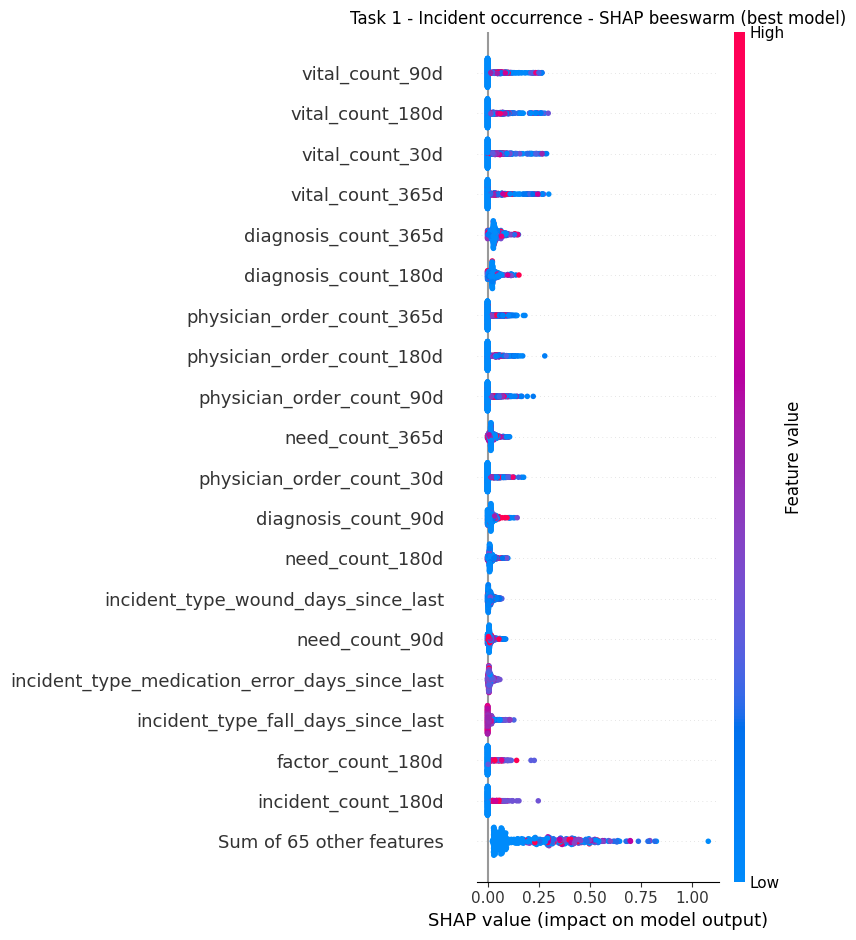

,task,target_label,factual_pred_label,counterfactual_pred_label,distance_zspace,factual_index,counterfactual_index,top_changed_features
0,Task 1 - Incident occurrence,0,1,0,2.361511,6166,7207,incident_type_medication_error_days_since_last...
1,Task 1 - Incident occurrence,1,0,1,0.325332,2851,3994,incident_type_medication_error_days_since_last...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'vital_count_90d': 'N', 'vital_count_180d': 'N', 'vital_count_30d': 'N', 'vital_count_365d': 'N', 'diagnosis_count_365d': 'N', 'diagnosis_count_180d': 'N', 'outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'vital_count_90d': 'N', 'vital_count_180d': 'N', 'vital_count_30d': 'N', 'vital_count_365d': 'N', 'diagnosis_count_365d': 'N', 'diagnosis_count_180d': 'N', 'outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'vital_count_90d': 'N', 'vital_count_180d': 'N', 'vital_count_30d': 'N', 'vital_count_365d': 'N', 'diagnosis_count_365d': 'N', 'diagnosis_count_180d': 'N', 'outcome': 'N'}
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
INFO:dowhy.causal_model:Model to find the causal effect of 

[Task 1 - Incident occurrence] causal analysis summary
Top features used: ['vital_count_90d', 'vital_count_180d', 'vital_count_30d', 'vital_count_365d', 'diagnosis_count_365d', 'diagnosis_count_180d']
Learned edges: [('vital_count_90d', 'vital_count_30d'), ('vital_count_90d', 'diagnosis_count_365d'), ('vital_count_180d', 'vital_count_90d'), ('vital_count_30d', 'diagnosis_count_365d'), ('vital_count_30d', 'diagnosis_count_180d'), ('vital_count_365d', 'vital_count_180d'), ('vital_count_365d', 'diagnosis_count_365d'), ('vital_count_365d', 'outcome'), ('vital_count_365d', 'diagnosis_count_180d'), ('diagnosis_count_365d', 'diagnosis_count_180d'), ('diagnosis_count_365d', 'outcome')]
Treatment: vital_count_365d -> Outcome: outcome
Estimated ATE (linear regression): 5.140642121712058e-05


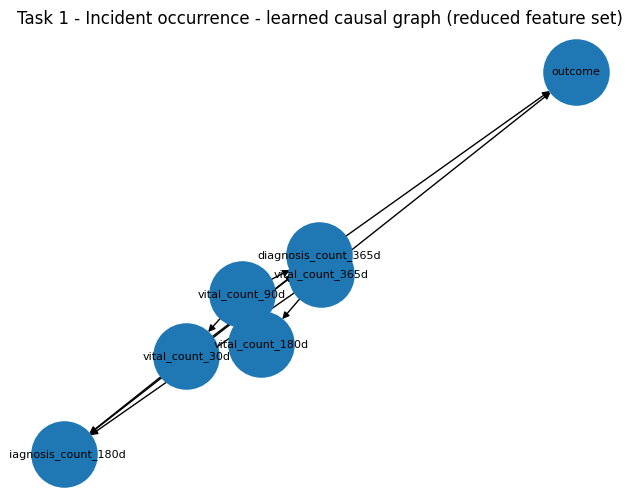


=== Task 2 - Incident type | best model: lightgbm ===
[Task 2 - Incident type] input shapes -> X: (6771, 98), y: (6771,)
[Fold 1] skipped due to empty split after resident overlap filtering.
[Fold 2] skipped due to empty split after resident overlap filtering.
[Task 2 - Incident type] pooled test shapes -> X: (2058, 94), y_true: (2058,), y_pred: (2058,)


PermutationExplainer explainer: 446it [00:32,  9.47it/s]                         


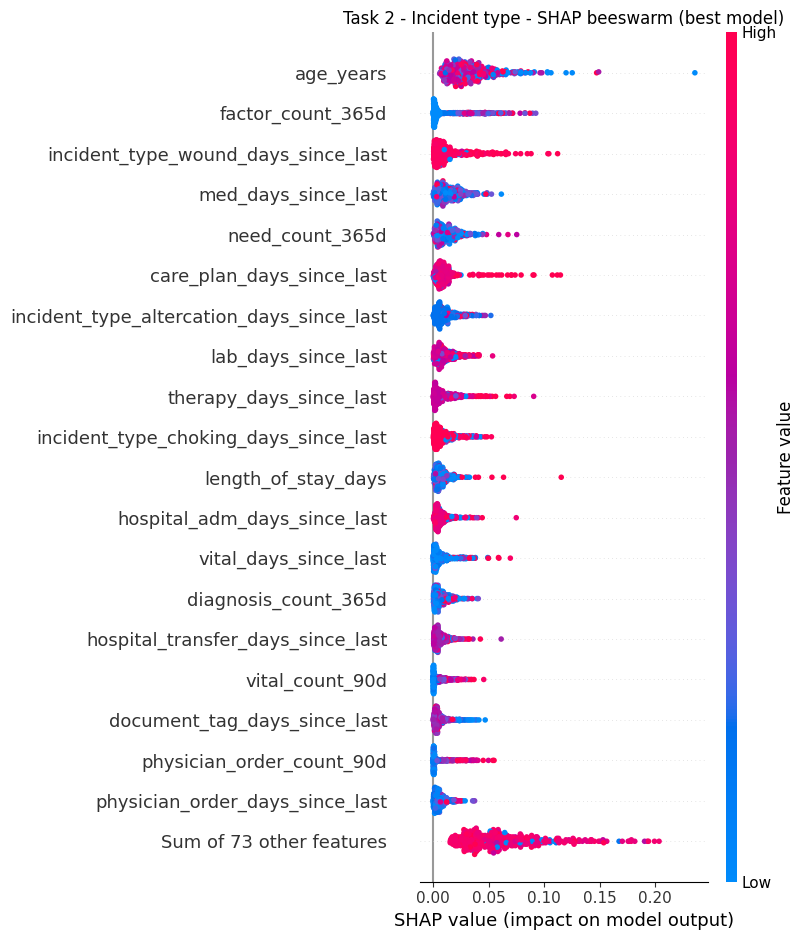

,task,target_label,factual_pred_label,counterfactual_pred_label,distance_zspace,factual_index,counterfactual_index,top_changed_features
0,Task 2 - Incident type,Altercation,Fall,Altercation,2.287563,1031,1580,"care_plan_days_since_last, hospital_transfer_d..."
1,Task 2 - Incident type,Choking,Fall,Choking,2.336787,1031,713,"incident_type_choking_days_since_last, vital_c..."
2,Task 2 - Incident type,Elopement,Fall,Elopement,4.181746,1031,1725,"diagnosis_days_since_last, care_plan_days_sinc..."
3,Task 2 - Incident type,Fall,Wound,Fall,1.349410,2000,681,"incident_type_choking_days_since_last, vital_c..."
4,Task 2 - Incident type,Medication Error,Fall,Medication Error,2.511102,1031,832,"hospital_adm_days_since_last, hospital_transfe..."
5,Task 2 - Incident type,Wound,Fall,Wound,1.861332,1031,819,"incident_type_choking_days_since_last, hospita..."


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age_years': 'N', 'factor_days_since_last': 'N', 'incident_type_elopement_days_since_last': 'N', 'need_count_180d': 'N', 'physician_order_count_90d': 'N', 'care_plan_days_since_last': 'N', 'is_Fall': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age_years': 'N', 'factor_days_since_last': 'N', 'incident_type_elopement_days_since_last': 'N', 'need_count_180d': 'N', 'physician_order_count_90d': 'N', 'care_plan_days_since_last': 'N', 'is_Fall': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age_years': 'N', 'factor_days_since_last': 'N', 'incident_type_elopement_days_since_last': 'N', 'need_count_180d': 'N', 'physician_order_count_90d': 'N', 'care_plan_days_since_last': 'N', 'is_Fall': 'N'}
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No mod

NetworkXError: The node is_Fall is not in the digraph.

In [10]:



def _collect_best_model_test_pool(
    X: pd.DataFrame,
    y: pd.Series,
    model_name: str,
    is_multiclass: bool,
) -> Dict[str, object]:
    """Fit only one model across folds and collect test-only artifacts."""
    data = X.copy()
    data[TIME_COL] = pd.to_datetime(data[TIME_COL], errors="coerce")
    order = np.argsort(data[TIME_COL].to_numpy())
    data = data.iloc[order].reset_index(drop=True)
    y = y.iloc[order].reset_index(drop=True)

    folds = _build_time_splits_without_resident_overlap(data, n_splits=K_FOLDS)
    fold_artifacts: List[Dict[str, object]] = []

    x_test_all: List[pd.DataFrame] = []
    y_true_all: List[pd.Series] = []
    y_pred_all: List[pd.Series] = []

    for fold_id, train_idx, test_idx in folds:
        x_train_df = data.iloc[train_idx].copy()
        x_test_df = data.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        x_train_df = x_train_df.drop(columns=DROP_FEATURE_COLS, errors="ignore")
        x_test_df = x_test_df.drop(columns=DROP_FEATURE_COLS, errors="ignore")

        x_train_df = x_train_df.apply(pd.to_numeric, errors="coerce")
        x_test_df = x_test_df.apply(pd.to_numeric, errors="coerce")

        imputer = IterativeImputer(random_state=RANDOM_STATE)
        x_train = imputer.fit_transform(x_train_df)
        x_test = imputer.transform(x_test_df)

        label_encoder = None
        if is_multiclass:
            label_encoder = LabelEncoder()
            y_train_enc = label_encoder.fit_transform(y_train.astype(str))

            known_classes = set(label_encoder.classes_)
            test_known_mask = y_test.astype(str).isin(known_classes).to_numpy()
            if not test_known_mask.all():
                x_test = x_test[test_known_mask]
                y_test = y_test.iloc[np.flatnonzero(test_known_mask)]

            if len(y_test) == 0:
                continue

            y_test_enc = label_encoder.transform(y_test.astype(str))
        else:
            y_train_enc = y_train.astype(int).to_numpy()
            y_test_enc = y_test.astype(int).to_numpy()

        if len(np.unique(y_train_enc)) < 2 or x_test.shape[0] == 0:
            continue

        model = MODEL_BUILDERS[model_name]()

        try:
            model.fit(x_train, y_train_enc)
            y_pred_enc = model.predict(x_test)
        except Exception as exc:
            print(f"[Fold {fold_id}][{model_name}] skipped during best-model analysis. Error: {exc}")
            continue

        # IterativeImputer can drop columns that are entirely missing in the train fold.
        # Use the imputer output names to keep matrix shape and column names consistent.
        try:
            imputed_feature_names = list(imputer.get_feature_names_out(x_train_df.columns))
        except Exception:
            # Safe fallback for older sklearn variants.
            imputed_feature_names = list(x_train_df.columns[: x_train.shape[1]])

        x_train_pd = pd.DataFrame(x_train, columns=imputed_feature_names)
        x_test_pd = pd.DataFrame(x_test, columns=imputed_feature_names)

        if is_multiclass and label_encoder is not None:
            y_true_fold = pd.Series(label_encoder.inverse_transform(y_test_enc), index=y_test.index)
            y_pred_fold = pd.Series(label_encoder.inverse_transform(y_pred_enc), index=y_test.index)
        else:
            y_true_fold = pd.Series(y_test_enc, index=y_test.index)
            y_pred_fold = pd.Series(y_pred_enc, index=y_test.index)

        if not (x_test_pd.shape[0] == y_true_fold.shape[0] == y_pred_fold.shape[0]):
            raise RuntimeError(
                f"[Fold {fold_id}] mismatch: "
                f"X_test={x_test_pd.shape[0]}, y_true={y_true_fold.shape[0]}, y_pred={y_pred_fold.shape[0]}"
            )

        fold_artifacts.append(
            {
                "fold_id": fold_id,
                "model": model,
                "x_train": x_train_pd,
                "x_test": x_test_pd,
                "y_true": y_true_fold,
                "y_pred": y_pred_fold,
                "feature_names": imputed_feature_names,
            }
        )

        x_test_all.append(x_test_pd)
        y_true_all.append(y_true_fold)
        y_pred_all.append(y_pred_fold)

    if len(fold_artifacts) == 0:
        raise RuntimeError(f"No valid fold artifacts available for best model '{model_name}'.")

    x_test_all_pd = pd.concat(x_test_all, axis=0, ignore_index=True)
    y_true_all_pd = pd.concat(y_true_all, axis=0, ignore_index=True)
    y_pred_all_pd = pd.concat(y_pred_all, axis=0, ignore_index=True)

    if not (x_test_all_pd.shape[0] == y_true_all_pd.shape[0] == y_pred_all_pd.shape[0]):
        raise RuntimeError(
            "Mismatch between pooled test feature rows and labels: "
            f"X={x_test_all_pd.shape[0]}, y_true={y_true_all_pd.shape[0]}, y_pred={y_pred_all_pd.shape[0]}"
        )

    return {
        "fold_artifacts": fold_artifacts,
        "x_test_all": x_test_all_pd,
        "y_true_all": y_true_all_pd,
        "y_pred_all": y_pred_all_pd,
    }


def _shap_beeswarm_for_fold(
    fold_artifact: Dict[str, object],
    task_title: str,
    max_display: int = 20,
) -> Tuple[shap.Explanation, np.ndarray]:
    """Create SHAP explanation and beeswarm plot for one fold."""
    model = fold_artifact["model"]
    x_train = fold_artifact["x_train"]
    x_test = fold_artifact["x_test"]

    background_n = min(300, x_train.shape[0])
    test_n = min(500, x_test.shape[0])
    x_background = x_train.sample(n=background_n, random_state=RANDOM_STATE)
    x_plot = x_test.sample(n=test_n, random_state=RANDOM_STATE)

    explainer = shap.Explainer(model.predict_proba, x_background)
    shap_values = explainer(x_plot)

    if shap_values.values.ndim == 3:
        # Multi-output case: aggregate across outputs to keep a single beeswarm.
        agg_values = np.mean(np.abs(shap_values.values), axis=2)
        if np.ndim(shap_values.base_values) == 2:
            agg_base = np.mean(shap_values.base_values, axis=1)
        else:
            agg_base = shap_values.base_values
        shap_plot_values = shap.Explanation(
            values=agg_values,
            base_values=agg_base,
            data=shap_values.data,
            feature_names=shap_values.feature_names,
        )
    else:
        shap_plot_values = shap_values

    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_plot_values, max_display=max_display, show=False)
    plt.title(f"{task_title} - SHAP beeswarm (best model)")
    plt.tight_layout()
    plt.show()

    mean_abs_importance = np.abs(shap_plot_values.values).mean(axis=0)
    return shap_plot_values, mean_abs_importance


def _build_test_only_counterfactuals(
    x_test_all: pd.DataFrame,
    y_pred_all: pd.Series,
    task_title: str,
    top_k_changed_features: int = 6,
) -> pd.DataFrame:
    """For each label, find nearest test-only sample predicted as that label."""
    x_cf = x_test_all.copy().apply(pd.to_numeric, errors="coerce")
    labels = pd.Series(y_pred_all).astype(str).reset_index(drop=True)

    # Robust NaN handling: concat across folds may introduce missing values.
    x_cf = x_cf.dropna(axis=1, how="all")
    x_cf = x_cf.fillna(x_cf.median(numeric_only=True))
    x_cf = x_cf.fillna(0.0)

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_cf)

    results = []
    unique_labels = sorted(labels.unique())

    for target_label in unique_labels:
        target_idx = np.flatnonzero((labels == target_label).to_numpy())
        factual_pool_idx = np.flatnonzero((labels != target_label).to_numpy())

        if len(target_idx) == 0:
            continue

        if len(factual_pool_idx) == 0:
            # Degenerate case: all predictions are the same class.
            factual_pool_idx = target_idx

        factual_centroid = x_scaled[factual_pool_idx].mean(axis=0, keepdims=True)
        factual_idx = factual_pool_idx[
            int(np.argmin(pairwise_distances(x_scaled[factual_pool_idx], factual_centroid).ravel()))
        ]

        distances = pairwise_distances(
            x_scaled[[factual_idx]],
            x_scaled[target_idx],
            metric="euclidean",
        ).ravel()

        nearest_target_local = int(np.argmin(distances))
        cf_idx = target_idx[nearest_target_local]

        factual_row = x_cf.iloc[factual_idx]
        counterfactual_row = x_cf.iloc[cf_idx]
        abs_deltas = (counterfactual_row - factual_row).abs().sort_values(ascending=False)
        top_changed = abs_deltas.head(top_k_changed_features).index.tolist()

        results.append(
            {
                "task": task_title,
                "target_label": target_label,
                "factual_pred_label": labels.iloc[factual_idx],
                "counterfactual_pred_label": labels.iloc[cf_idx],
                "distance_zspace": float(distances[nearest_target_local]),
                "factual_index": int(factual_idx),
                "counterfactual_index": int(cf_idx),
                "top_changed_features": ", ".join(top_changed),
            }
        )

    result_df = pd.DataFrame(results)
    display(result_df)
    return result_df


def _run_simple_causal_analysis(
    x_test_all: pd.DataFrame,
    y_true_all: pd.Series,
    feature_importance: np.ndarray,
    task_title: str,
    is_multiclass: bool,
    n_features: int = 6,
) -> Dict[str, object]:
    """Learn a small causal graph automatically and estimate one treatment effect."""
    ranked_idx = np.argsort(feature_importance)[::-1]
    top_features = [x_test_all.columns[i] for i in ranked_idx[: min(n_features, x_test_all.shape[1])]]

    analysis_df_num = x_test_all[top_features].copy()

    if is_multiclass:
        positive_label = y_true_all.astype(str).mode(dropna=True).iloc[0]
        outcome_name = f"is_{positive_label}"
        outcome_series = (y_true_all.astype(str) == positive_label).astype(int)
    else:
        outcome_name = "outcome"
        outcome_series = y_true_all.astype(int)

    analysis_df_num[outcome_name] = outcome_series.to_numpy()
    analysis_df_num = analysis_df_num.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    # Structure learning on discretized variables for stability.
    # Keep all columns as explicit integer-coded categories so pgmpy does not need dtype inference.
    analysis_df_disc = analysis_df_num.copy()
    for col in top_features:
        try:
            bins = pd.qcut(analysis_df_disc[col], q=4, duplicates="drop")
        except Exception:
            bins = analysis_df_disc[col]
        analysis_df_disc[col] = pd.Categorical(bins).codes.astype("int64")

    analysis_df_disc[outcome_name] = pd.Categorical(analysis_df_disc[outcome_name]).codes.astype("int64")

    hc = HillClimbSearch(analysis_df_disc)
    learned_dag = hc.estimate(scoring_method=BicScore(analysis_df_disc), show_progress=False)
    learned_edges = list(learned_dag.edges())

    if len(learned_edges) == 0:
        treatment = top_features[0]
        learned_edges = [(treatment, outcome_name)]
    else:
        parents_of_outcome = [u for (u, v) in learned_edges if v == outcome_name]
        treatment = parents_of_outcome[0] if len(parents_of_outcome) > 0 else learned_edges[0][0]

    graph_dot = "digraph {\n" + "\n".join([f'  "{u}" -> "{v}";' for u, v in learned_edges]) + "\n}"

    causal_model = CausalModel(
        data=analysis_df_num,
        treatment=treatment,
        outcome=outcome_name,
        graph=graph_dot,
    )
    identified_estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
    causal_estimate = causal_model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
    )

    print(f"[{task_title}] causal analysis summary")
    print(f"Top features used: {top_features}")
    print(f"Learned edges: {learned_edges}")
    print(f"Treatment: {treatment} -> Outcome: {outcome_name}")
    print(f"Estimated ATE (linear regression): {causal_estimate.value}")

    g = nx.DiGraph()
    g.add_edges_from(learned_edges)
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(g, seed=RANDOM_STATE)
    nx.draw_networkx(g, pos=pos, with_labels=True, node_size=2200, font_size=8, arrows=True)
    plt.title(f"{task_title} - learned causal graph (reduced feature set)")
    plt.axis("off")
    plt.show()

    return {
        "top_features": top_features,
        "edges": learned_edges,
        "treatment": treatment,
        "outcome": outcome_name,
        "ate": causal_estimate.value,
    }


def run_advanced_analyses_for_task(
    X: pd.DataFrame,
    y: pd.Series,
    results_df: pd.DataFrame,
    task_title: str,
    is_multiclass: bool,
) -> Dict[str, object]:
    """End-to-end post-hoc analysis for best model in a task."""
    if X.shape[0] != y.shape[0]:
        raise ValueError(f"[{task_title}] input mismatch: X rows={X.shape[0]} vs y rows={y.shape[0]}")

    best_model_name = results_df.sort_values("FNR", ascending=True).iloc[0]["model"]
    print(f"\n=== {task_title} | best model: {best_model_name} ===")
    print(f"[{task_title}] input shapes -> X: {X.shape}, y: {y.shape}")

    pool = _collect_best_model_test_pool(
        X=X,
        y=y,
        model_name=best_model_name,
        is_multiclass=is_multiclass,
    )

    fold_artifacts = pool["fold_artifacts"]
    print(
        f"[{task_title}] pooled test shapes -> X: {pool['x_test_all'].shape}, "
        f"y_true: {pool['y_true_all'].shape}, y_pred: {pool['y_pred_all'].shape}"
    )

    # Use the fold with the largest test split for SHAP and per-instance narratives.
    best_fold = sorted(fold_artifacts, key=lambda d: d["x_test"].shape[0], reverse=True)[0]

    shap_values, feature_importance = _shap_beeswarm_for_fold(
        fold_artifact=best_fold,
        task_title=task_title,
    )

    counterfactuals_df = _build_test_only_counterfactuals(
        x_test_all=pool["x_test_all"],
        y_pred_all=pool["y_pred_all"],
        task_title=task_title,
    )

    causal_summary = _run_simple_causal_analysis(
        x_test_all=pool["x_test_all"],
        y_true_all=pool["y_true_all"],
        feature_importance=feature_importance,
        task_title=task_title,
        is_multiclass=is_multiclass,
    )

    return {
        "best_model": best_model_name,
        "shap_values": shap_values,
        "counterfactuals": counterfactuals_df,
        "causal_summary": causal_summary,
    }


print(f"Task 1 input tables -> X: {task1_X.shape}, y: {task1_y.shape}")
print(f"Task 2 input tables -> X: {task2_X.shape}, y: {task2_y.shape}")
assert task1_X.shape[0] == task1_y.shape[0], "Task 1 mismatch between feature rows and labels"
assert task2_X.shape[0] == task2_y.shape[0], "Task 2 mismatch between feature rows and labels"

advanced_task1 = run_advanced_analyses_for_task(
    X=task1_X,
    y=task1_y,
    results_df=results_task1,
    task_title="Task 1 - Incident occurrence",
    is_multiclass=False,
)

advanced_task2 = run_advanced_analyses_for_task(
    X=task2_X,
    y=task2_y,
    results_df=results_task2,
    task_title="Task 2 - Incident type",
    is_multiclass=True,
)


## Cost Analysis: Ground Truth vs Model-Based Estimates

This section combines the best Task 1 model (incident occurrence) and the best Task 2 model (incident type) to estimate TIG expenditure over time.

We compare three monthly cost series on the testing folds: (1) historical ground-truth costs, (2) discrete model-based costs using top-1 class decisions, and (3) probabilistic model-based expected costs using full predicted probabilities.

Best Task 1 model: bernoulli_nb
Best Task 2 model: lightgbm

Cost mapping used:
{'Fall': 3500.0, 'Medication Error': 5000.0, 'Wound': 4000.0, 'Elopement': 2500.0, 'Altercation': 2500.0, 'Any Other Incidents': 1000.0}


,Scenario,Total Cost ($),Abs Error vs Truth ($)
0,Ground Truth,"$11,449,000",$0
1,Estimated (Discrete),"$22,237,000","$10,788,000"
2,Estimated (Probabilistic),"$22,132,620","$10,683,620"


,month,ground_truth_cost,estimated_cost_discrete,estimated_cost_probabilistic
0,2021-08-01,3500.0,3500.0,3557.743610
1,2021-09-01,0.0,0.0,37.989315
2,2021-10-01,0.0,0.0,133.366478
3,2021-11-01,0.0,0.0,238.561260
4,2021-12-01,0.0,3500.0,4089.902505
5,2022-01-01,4500.0,7000.0,7650.847896
6,2022-02-01,1000.0,7500.0,7816.346346
7,2022-03-01,1000.0,7000.0,7195.012954
8,2022-04-01,0.0,0.0,2650.989790
9,2022-05-01,7000.0,0.0,3286.564988


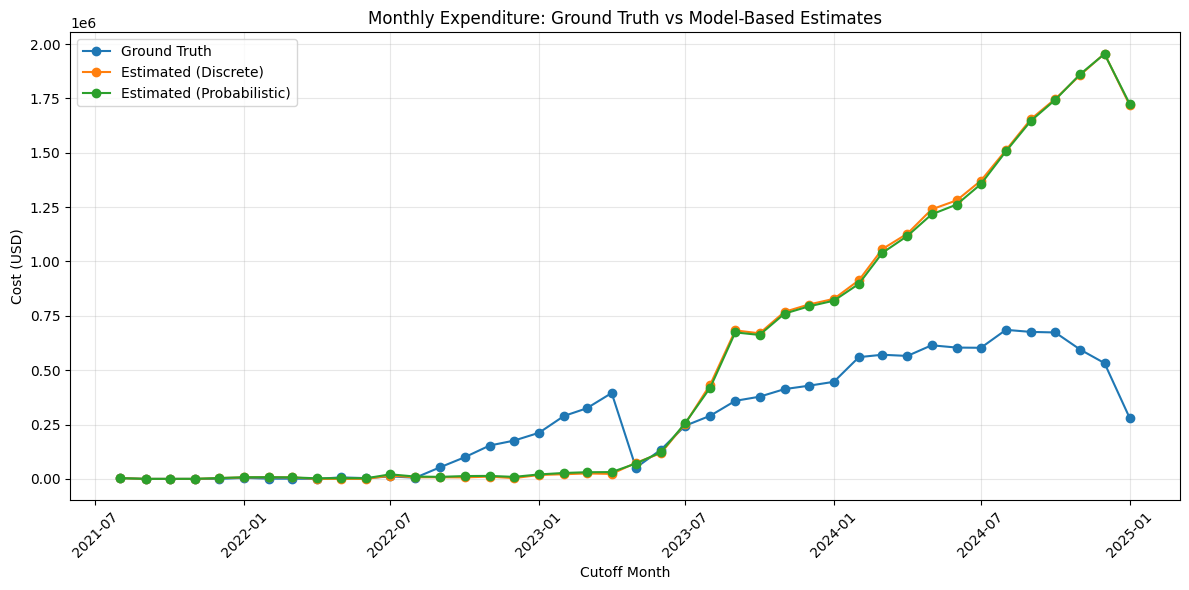

In [11]:
# Cost assumptions (USD)
INCIDENT_COST_MAP = {
    "Fall": 3500.0,
    "Medication Error": 5000.0,
    "Wound": 4000.0,
    "Elopement": 2500.0,
    "Altercation": 2500.0,
}
DEFAULT_INCIDENT_COST = 1000.0  # Any other incidents (e.g., Choking, unseen labels)


def _incident_cost(label) -> float:
    if pd.isna(label):
        return DEFAULT_INCIDENT_COST
    return INCIDENT_COST_MAP.get(str(label), DEFAULT_INCIDENT_COST)


# Select best models from each task (same criterion used above: lower FNR is better)
best_task1_model = results_task1.sort_values("FNR", ascending=True).iloc[0]["model"]
best_task2_model = results_task2.sort_values("FNR", ascending=True).iloc[0]["model"]

print(f"Best Task 1 model: {best_task1_model}")
print(f"Best Task 2 model: {best_task2_model}")


# Build aligned targets on Task 1 universe
aligned_X = task1_X.copy()
aligned_X[TIME_COL] = pd.to_datetime(aligned_X[TIME_COL], errors="coerce")
aligned_y_occ = task1_y.astype(int).copy()

aligned_y_type = pd.Series(index=task1_X.index, dtype="object")
aligned_y_type.loc[task2_y.index] = task2_y.astype(str).values

# Keep deterministic temporal order
order = np.argsort(aligned_X[TIME_COL].to_numpy())
aligned_X = aligned_X.iloc[order].reset_index(drop=True)
aligned_y_occ = aligned_y_occ.iloc[order].reset_index(drop=True)
aligned_y_type = aligned_y_type.iloc[order].reset_index(drop=True)

folds = _build_time_splits_without_resident_overlap(aligned_X, n_splits=K_FOLDS)

cost_rows = []

for fold_id, train_idx, test_idx in folds:
    # Fold slices
    x_train_all = aligned_X.iloc[train_idx].copy()
    x_test_all = aligned_X.iloc[test_idx].copy()

    y_train_occ = aligned_y_occ.iloc[train_idx].copy()
    y_test_occ = aligned_y_occ.iloc[test_idx].copy()
    y_test_type = aligned_y_type.iloc[test_idx].copy()

    # -----------------------------
    # Task 1 model (binary)
    # -----------------------------
    x_train_t1_df = x_train_all.drop(columns=DROP_FEATURE_COLS, errors="ignore").apply(pd.to_numeric, errors="coerce")
    x_test_t1_df = x_test_all.drop(columns=DROP_FEATURE_COLS, errors="ignore").apply(pd.to_numeric, errors="coerce")

    imputer_t1 = IterativeImputer(random_state=RANDOM_STATE)
    x_train_t1 = imputer_t1.fit_transform(x_train_t1_df)
    x_test_t1 = imputer_t1.transform(x_test_t1_df)

    y_train_occ_np = y_train_occ.astype(int).to_numpy()
    if len(np.unique(y_train_occ_np)) < 2 or x_test_t1.shape[0] == 0:
        continue

    model_t1 = MODEL_BUILDERS[best_task1_model]()
    model_t1.fit(x_train_t1, y_train_occ_np)

    y_pred_occ = model_t1.predict(x_test_t1).astype(int)
    p_occ = model_t1.predict_proba(x_test_t1)[:, 1]

    # -----------------------------
    # Task 2 model (multi-class), trained only on incident rows from train
    # -----------------------------
    train_incident_mask = y_train_occ.astype(int).to_numpy() == 1
    if train_incident_mask.sum() == 0:
        continue

    x_train_t2_source = x_train_all.iloc[np.flatnonzero(train_incident_mask)].copy()
    y_train_t2_source = aligned_y_type.iloc[train_idx].iloc[np.flatnonzero(train_incident_mask)].copy()

    known_type_mask = y_train_t2_source.notna().to_numpy()
    if known_type_mask.sum() == 0:
        continue

    x_train_t2_source = x_train_t2_source.iloc[np.flatnonzero(known_type_mask)]
    y_train_t2 = y_train_t2_source.iloc[np.flatnonzero(known_type_mask)].astype(str)

    if y_train_t2.nunique() < 2:
        continue

    x_train_t2_df = x_train_t2_source.drop(columns=DROP_FEATURE_COLS, errors="ignore").apply(pd.to_numeric, errors="coerce")
    x_test_t2_df = x_test_all.drop(columns=DROP_FEATURE_COLS, errors="ignore").apply(pd.to_numeric, errors="coerce")

    imputer_t2 = IterativeImputer(random_state=RANDOM_STATE)
    x_train_t2 = imputer_t2.fit_transform(x_train_t2_df)
    x_test_t2 = imputer_t2.transform(x_test_t2_df)

    le_t2 = LabelEncoder()
    y_train_t2_enc = le_t2.fit_transform(y_train_t2)

    model_t2 = MODEL_BUILDERS[best_task2_model]()
    model_t2.fit(x_train_t2, y_train_t2_enc)

    y_pred_t2_enc = model_t2.predict(x_test_t2)
    y_pred_t2 = le_t2.inverse_transform(y_pred_t2_enc)

    p_type = model_t2.predict_proba(x_test_t2)
    type_cost_vector = np.array([_incident_cost(lbl) for lbl in le_t2.classes_], dtype=float)
    expected_type_cost = p_type @ type_cost_vector

    # -----------------------------
    # Cost assembly per resident-month in test fold
    # -----------------------------
    months = pd.to_datetime(x_test_all[TIME_COL], errors="coerce").dt.to_period("M").dt.to_timestamp()

    for i in range(x_test_all.shape[0]):
        true_occ_i = int(y_test_occ.iloc[i])
        true_type_i = y_test_type.iloc[i]

        ground_truth_cost = _incident_cost(true_type_i) if true_occ_i == 1 else 0.0
        estimated_cost_discrete = float(y_pred_occ[i]) * _incident_cost(y_pred_t2[i])
        estimated_cost_probabilistic = float(p_occ[i]) * float(expected_type_cost[i])

        cost_rows.append(
            {
                "month": months.iloc[i],
                "ground_truth_cost": ground_truth_cost,
                "estimated_cost_discrete": estimated_cost_discrete,
                "estimated_cost_probabilistic": estimated_cost_probabilistic,
            }
        )


if len(cost_rows) == 0:
    raise RuntimeError("No cost rows were generated. Please inspect fold/model filtering conditions.")

cost_df = pd.DataFrame(cost_rows)
monthly_costs = (
    cost_df.groupby("month", as_index=False)[
        ["ground_truth_cost", "estimated_cost_discrete", "estimated_cost_probabilistic"]
    ]
    .sum()
    .sort_values("month")
)

# Totals comparison table
truth_total = monthly_costs["ground_truth_cost"].sum()
discrete_total = monthly_costs["estimated_cost_discrete"].sum()
prob_total = monthly_costs["estimated_cost_probabilistic"].sum()

comparison = pd.DataFrame(
    {
        "Scenario": ["Ground Truth", "Estimated (Discrete)", "Estimated (Probabilistic)"],
        "Total Cost ($)": [truth_total, discrete_total, prob_total],
    }
)
comparison["Abs Error vs Truth ($)"] = (comparison["Total Cost ($)"] - truth_total).abs()

styled_comparison = (
    comparison.style.format({"Total Cost ($)": "${:,.0f}", "Abs Error vs Truth ($)": "${:,.0f}"})
    .background_gradient(cmap="Blues_r", subset=["Total Cost ($)", "Abs Error vs Truth ($)"])
)

print("\nCost mapping used:")
print({**INCIDENT_COST_MAP, "Any Other Incidents": DEFAULT_INCIDENT_COST})

display(styled_comparison)
display(monthly_costs.head(12))


# Monthly series chart over time
plt.figure(figsize=(12, 6))
plt.plot(monthly_costs["month"], monthly_costs["ground_truth_cost"], marker="o", label="Ground Truth")
plt.plot(monthly_costs["month"], monthly_costs["estimated_cost_discrete"], marker="o", label="Estimated (Discrete)")
plt.plot(monthly_costs["month"], monthly_costs["estimated_cost_probabilistic"], marker="o", label="Estimated (Probabilistic)")

plt.title("Monthly Expenditure: Ground Truth vs Model-Based Estimates")
plt.xlabel("Cutoff Month")
plt.ylabel("Cost (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()